# Classification Model: Predicting Red List Categories for Kenya's Data Deficient Species

This notebook builds a classification pipeline to predict the IUCN Red List category (Threatened / Non-Threatened / Extinct) for **Data Deficient species found in Kenya**, using all globally assessed non-DD species as training data.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Build Feature Matrix

In [47]:
# Load all processed datasets
base_taxa = pd.read_csv(r"../data/processed/base_taxa.csv")
countries = pd.read_csv(r"../data/processed/countries.csv")
habitats = pd.read_csv(r"../data/processed/habitats.csv")
threats = pd.read_csv(r"../data/processed/threats.csv")
uses = pd.read_csv(r"../data/processed/uses.csv")
conservation_needed = pd.read_csv(r"../data/processed/conservation_needed.csv")
research_needed = pd.read_csv(r"../data/processed/research_needed.csv")

print(f"Total species: {len(base_taxa):,}")

Total species: 39,024


In [48]:
# Create simplified target variable
def simplify_category(cat):
    threatened = ['Vulnerable', 'Endangered', 'Critically Endangered']
    non_threatened = ['Least Concern', 'Near Threatened', 'Not Applicable','Lower Risk/near threatened', 'Lower Risk/least concern','Lower Risk/conservation dependent']
    extinct = ['Extinct', 'Extinct in the Wild', 'Regionally Extinct']
    
    if cat in threatened:
        return 'Threatened'
    elif cat in non_threatened:
        return 'Non-Threatened'
    elif cat in extinct:
        return 'Extinct'
    else:
        return 'Data Deficient'

base_taxa['simplified_category'] = base_taxa['redlistCategory'].apply(simplify_category)

# Build count features from relational tables
count_tables = {
    'n_countries': countries,
    'n_habitats': habitats,
    'n_threats': threats,
    'n_uses': uses,
    'n_conservation': conservation_needed,
    'n_research': research_needed,
}

feature_df = base_taxa[['internalTaxonId', 'className', 'populationTrend', 'simplified_category']].copy()

for col_name, table in count_tables.items():
    counts = table.groupby('internalTaxonId').size().reset_index(name=col_name)
    feature_df = feature_df.merge(counts, on='internalTaxonId', how='left')
    feature_df[col_name] = feature_df[col_name].fillna(0).astype(int)

print(f"Feature matrix shape: {feature_df.shape}")
feature_df.head()

Feature matrix shape: (39024, 10)


,internalTaxonId,className,populationTrend,simplified_category,n_countries,n_habitats,n_threats,n_uses,n_conservation,n_research
0,10030,CHONDRICHTHYES,Decreasing,Non-Threatened,76,3,3,6,0,4
1,11200,CHONDRICHTHYES,Decreasing,Threatened,47,4,4,0,4,6
2,232775771,REPTILIA,Decreasing,Threatened,9,5,24,3,5,6
3,12696,REPTILIA,Decreasing,Threatened,3,4,7,2,11,10
4,12776,AMPHIBIA,Decreasing,Threatened,1,5,9,2,4,3


## 2. Identify Kenya's Data Deficient Species

In [49]:
# Filter for Kenya species
kenya_ids = set(countries[countries['countryCode'] == 'KE']['internalTaxonId'])

# Kenya DD species = species in Kenya AND classified as Data Deficient
kenya_dd = feature_df[
    (feature_df['internalTaxonId'].isin(kenya_ids)) &
    (feature_df['simplified_category'] == 'Data Deficient')
].copy()

print(f"Kenya DD species to predict: {len(kenya_dd)}")
print(f"\nTaxonomic class breakdown:")
print(kenya_dd['className'].value_counts().head(10))

Kenya DD species to predict: 335

Taxonomic class breakdown:
className
ACTINOPTERYGII    119
MAMMALIA           34
INSECTA            32
REPTILIA           22
HOLOTHUROIDEA      19
GASTROPODA         18
CEPHALOPODA        15
MAGNOLIOPSIDA      15
LILIOPSIDA         13
BIVALVIA           12
Name: count, dtype: int64


## 3. Prepare Train/Test Sets with One-Hot Encoding

In [50]:
# Separate training data (all non-DD species globally) and prediction data (Kenya DD)
train_pool = feature_df[feature_df['simplified_category'] != 'Data Deficient'].copy()

print(f"Training pool (non-DD, global): {len(train_pool):,}")
print(f"Prediction set (Kenya DD):      {len(kenya_dd)}")

# Define feature columns
cat_features = ['className', 'populationTrend']
num_features = ['n_countries', 'n_habitats', 'n_threats', 'n_uses', 'n_conservation', 'n_research']

# Target
y_all = train_pool['simplified_category']

# Train/test split (80/20, stratified)
train_idx, test_idx = train_test_split(
    train_pool.index, test_size=0.2, random_state=42, stratify=y_all
)

train_data = train_pool.loc[train_idx]
test_data = train_pool.loc[test_idx]

print(f"\nTrain: {len(train_data):,}, Test: {len(test_data):,}")

Training pool (non-DD, global): 35,404
Prediction set (Kenya DD):      335

Train: 28,323, Test: 7,081


In [51]:
# One-Hot Encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on training data only
ohe.fit(train_data[cat_features])

# Transform all three sets
train_cat_encoded = pd.DataFrame(
    ohe.transform(train_data[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=train_data.index
)
test_cat_encoded = pd.DataFrame(
    ohe.transform(test_data[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=test_data.index
)
kenya_dd_cat_encoded = pd.DataFrame(
    ohe.transform(kenya_dd[cat_features]),
    columns=ohe.get_feature_names_out(cat_features),
    index=kenya_dd.index
)

# Combine encoded categoricals with numeric features
X_train = pd.concat([train_data[num_features].reset_index(drop=True),
                      train_cat_encoded.reset_index(drop=True)], axis=1)
X_test = pd.concat([test_data[num_features].reset_index(drop=True),
                     test_cat_encoded.reset_index(drop=True)], axis=1)
X_kenya_dd = pd.concat([kenya_dd[num_features].reset_index(drop=True),
                         kenya_dd_cat_encoded.reset_index(drop=True)], axis=1)

y_train = train_data['simplified_category'].values
y_test = test_data['simplified_category'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"X_kenya_dd shape: {X_kenya_dd.shape}")
print(f"\nTotal features: {X_train.shape[1]} ({len(num_features)} numeric + {X_train.shape[1] - len(num_features)} one-hot encoded)")

X_train shape: (28323, 52)
X_test shape:  (7081, 52)
X_kenya_dd shape: (335, 52)

Total features: 52 (6 numeric + 46 one-hot encoded)


## 4. Handle Class Imbalance with SMOTE

Class distribution BEFORE SMOTE:
Non-Threatened    18217
Threatened         9946
Extinct             160
Name: count, dtype: int64



Class distribution AFTER SMOTE:
Threatened        18217
Non-Threatened    18217
Extinct           18217
Name: count, dtype: int64


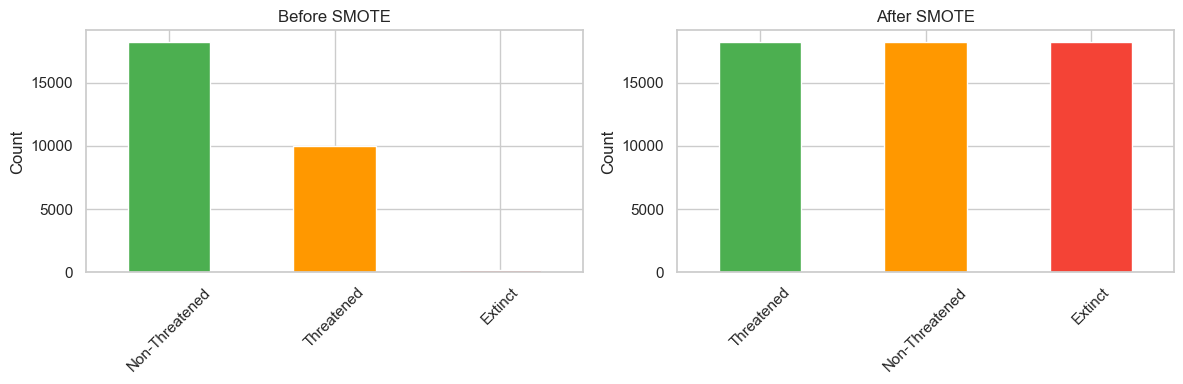

In [52]:
# Class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
before = pd.Series(y_train).value_counts()
print(before)
print()

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
after = pd.Series(y_train_smote).value_counts()
print(after)

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before.plot(kind='bar', ax=axes[0], color=['#4CAF50', '#FF9800', '#F44336'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

after.plot(kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800', '#F44336'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Logistic Regression

In [53]:
# Train Logistic Regression on SMOTE-balanced data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

# Evaluate on the original (unbalanced) test set
y_pred_lr = lr.predict(X_test)

print("Logistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Classification Report:
                precision    recall  f1-score   support

       Extinct       0.05      0.85      0.09        40
Non-Threatened       0.92      0.74      0.82      4554
    Threatened       0.72      0.78      0.75      2487

      accuracy                           0.76      7081
     macro avg       0.56      0.79      0.55      7081
  weighted avg       0.85      0.76      0.79      7081



d:\2-zindua\04-machine-learning-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


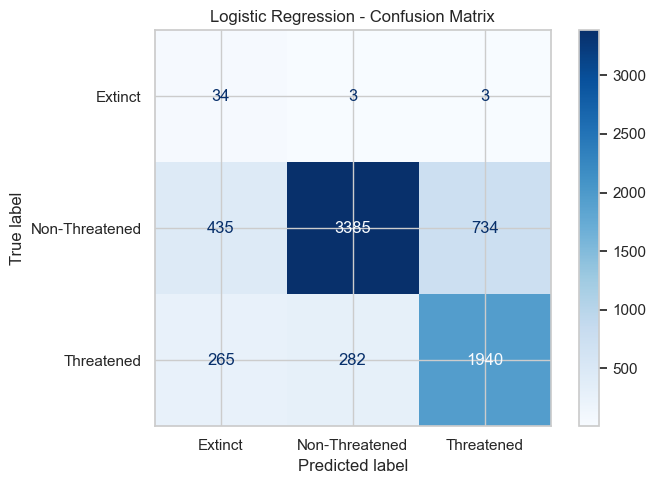

In [54]:
# Confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [55]:
# Cross-validation on SMOTE-balanced data
lr_cv_scores = cross_val_score(lr, X_train_smote, y_train_smote, cv=5, scoring='f1_weighted')
print(f"Logistic Regression - 5-Fold CV F1 (weighted): {lr_cv_scores}")
print(f"Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

d:\2-zindua\04-machine-learning-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\2-zindua\04-machine-learning-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules

Logistic Regression - 5-Fold CV F1 (weighted): [0.79340767 0.79947436 0.79886793 0.80147654 0.79709468]
Mean: 0.7981 (+/- 0.0027)


d:\2-zindua\04-machine-learning-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Random Forest

In [64]:
# Train Random Forest on SMOTE-balanced data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

# Evaluate on the original (unbalanced) test set
y_pred_rf = rf.predict(X_test)

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest - Classification Report:
                precision    recall  f1-score   support

       Extinct       0.19      0.60      0.29        40
Non-Threatened       0.93      0.87      0.90      4554
    Threatened       0.79      0.86      0.82      2487

      accuracy                           0.86      7081
     macro avg       0.63      0.77      0.67      7081
  weighted avg       0.88      0.86      0.87      7081



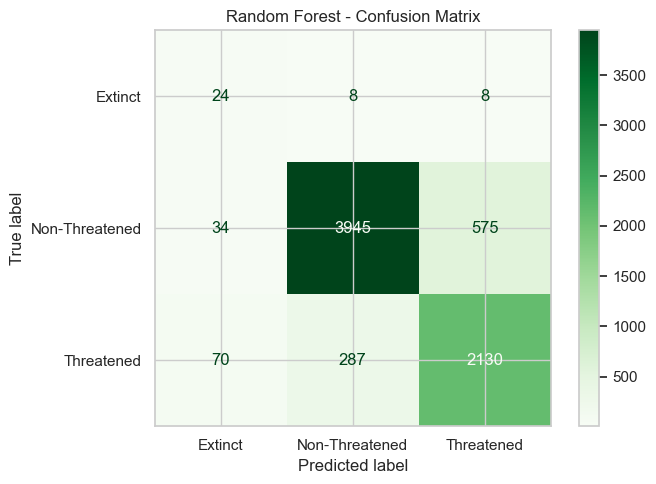

In [65]:
# Confusion matrix for Random Forest
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Greens')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

In [66]:
# Cross-validation
rf_cv_scores = cross_val_score(rf, X_train_smote, y_train_smote, cv=5, scoring='f1_weighted')
print(f"Random Forest - 5-Fold CV F1 (weighted): {rf_cv_scores}")
print(f"Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Random Forest - 5-Fold CV F1 (weighted): [0.91302506 0.90399063 0.91604229 0.9317708  0.93018397]
Mean: 0.9190 (+/- 0.0106)


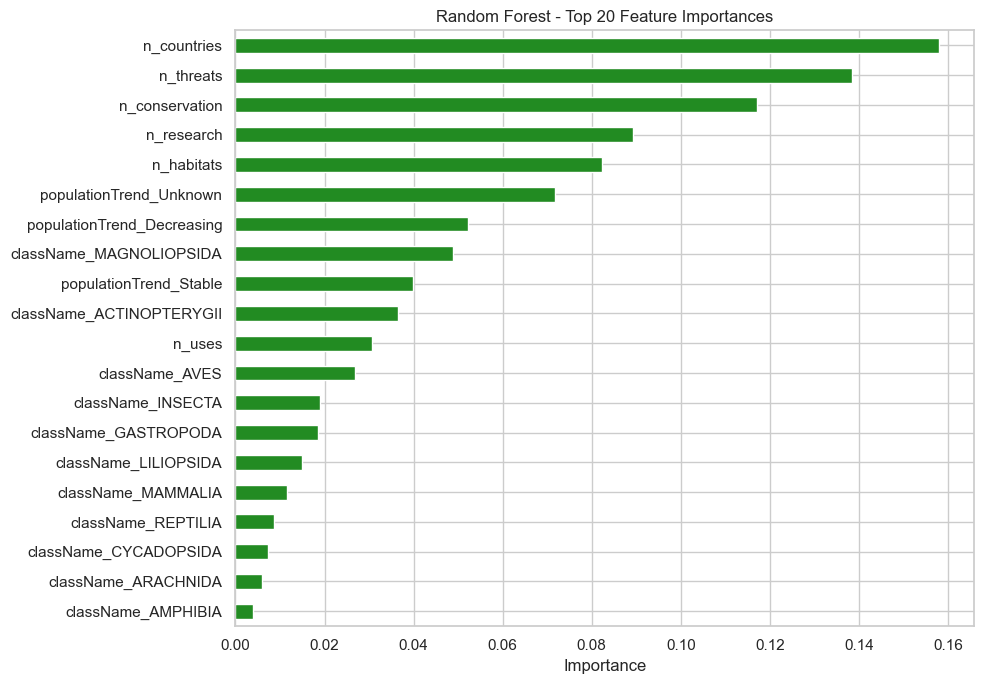

In [67]:
# Feature importance (top 20)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_20.sort_values().plot(kind='barh', color='forestgreen', ax=ax)
ax.set_title('Random Forest - Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Model Comparison

In [68]:
# Side-by-side comparison
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (weighted)', 'CV F1 Mean', 'CV F1 Std'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average='weighted'),
        lr_cv_scores.mean(),
        lr_cv_scores.std()
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average='weighted'),
        rf_cv_scores.mean(),
        rf_cv_scores.std()
    ]
})

comparison[['Logistic Regression', 'Random Forest']] = comparison[['Logistic Regression', 'Random Forest']].round(4)
comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.7568,0.8613
1,F1 (weighted),0.7938,0.8664
2,CV F1 Mean,0.7981,0.9190
3,CV F1 Std,0.0027,0.0106


## 8. Predict Red List Categories for Kenya's DD Species

In [70]:
# Predict using both models
kenya_dd_pred_lr = lr.predict(X_kenya_dd)
kenya_dd_pred_rf = rf.predict(X_kenya_dd)

# Build results dataframe
kenya_dd_results = kenya_dd[['internalTaxonId', 'className']].reset_index(drop=True)
kenya_dd_results['scientificName'] = base_taxa.set_index('internalTaxonId').loc[kenya_dd['internalTaxonId'].values, 'scientificName'].values
kenya_dd_results['pred_logistic_regression'] = kenya_dd_pred_lr
kenya_dd_results['pred_random_forest'] = kenya_dd_pred_rf

kenya_dd_results.head()

,internalTaxonId,className,scientificName,pred_logistic_regression,pred_random_forest
0,137075,INSECTA,Coptorhina nitefacta,Non-Threatened,Non-Threatened
1,137094,INSECTA,Onitis parvulus,Non-Threatened,Non-Threatened
2,137449,INSECTA,Copris morphaeus,Non-Threatened,Non-Threatened
3,137608,INSECTA,Onitis meyeri,Non-Threatened,Non-Threatened
4,137895,INSECTA,Onthophagus rugulipennis,Non-Threatened,Non-Threatened


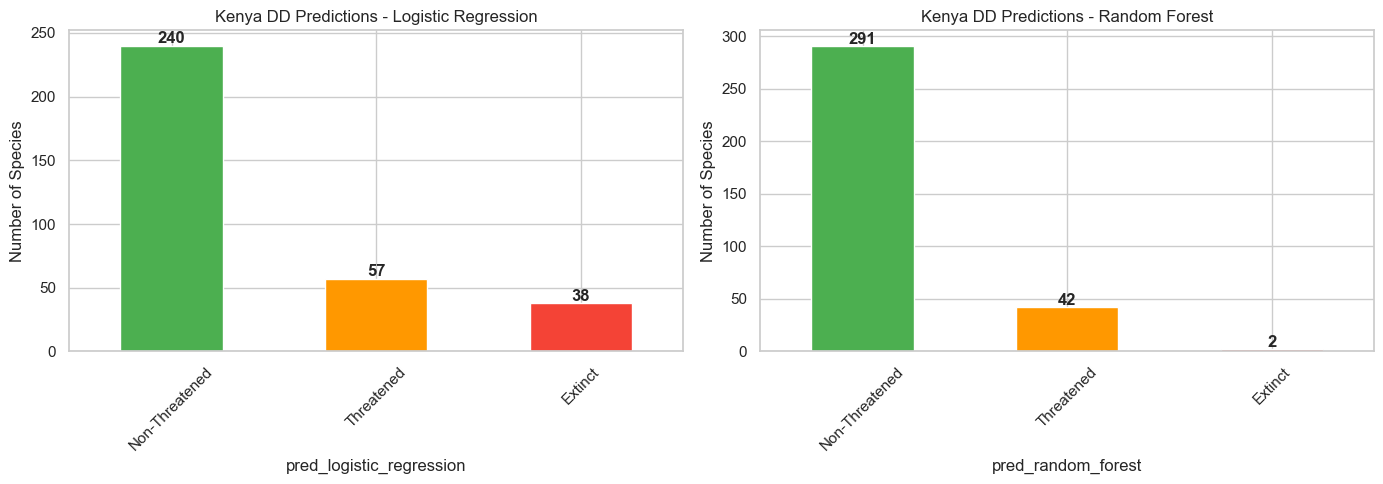

In [71]:
# Visualize prediction distributions from both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Non-Threatened': '#4CAF50', 'Threatened': '#FF9800', 'Extinct': '#F44336'}

for ax, col, title in zip(axes,
    ['pred_logistic_regression', 'pred_random_forest'],
    ['Logistic Regression', 'Random Forest']):
    
    counts = kenya_dd_results[col].value_counts()
    bar_colors = [colors.get(cat, 'grey') for cat in counts.index]
    counts.plot(kind='bar', color=bar_colors, ax=ax)
    ax.set_title(f'Kenya DD Predictions - {title}')
    ax.set_ylabel('Number of Species')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

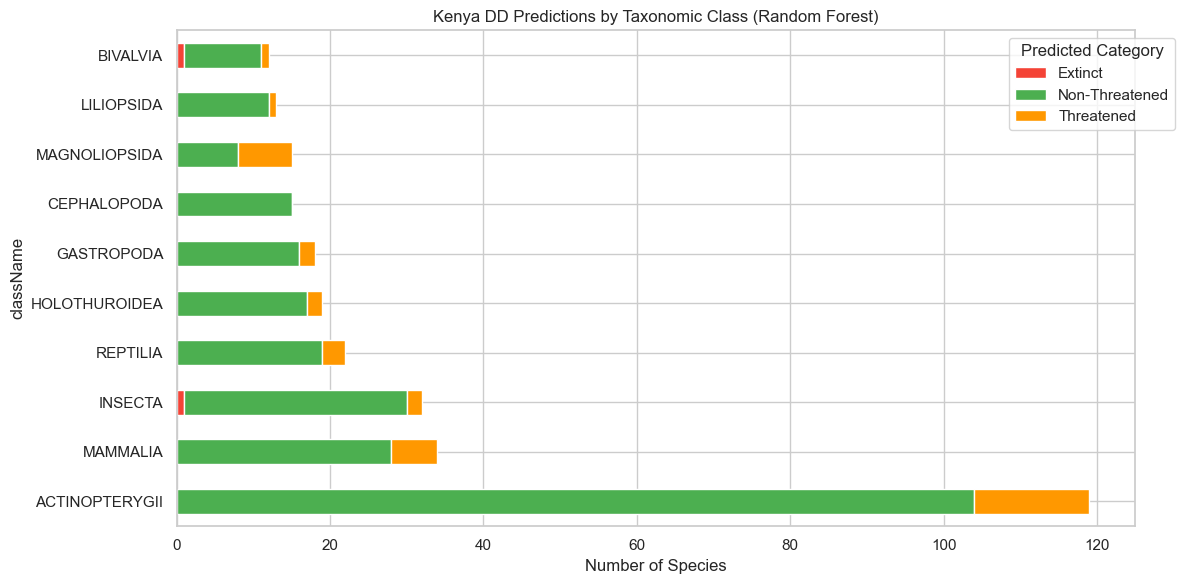

In [72]:
# Predicted category breakdown by taxonomic class (using Random Forest)
pred_by_class = pd.crosstab(kenya_dd_results['className'], kenya_dd_results['pred_random_forest'])
pred_by_class = pred_by_class.loc[pred_by_class.sum(axis=1).sort_values(ascending=False).head(10).index]

pred_by_class.plot(kind='barh', stacked=True, figsize=(12, 6),
                   color=['#F44336', '#4CAF50', '#FF9800'])
plt.title('Kenya DD Predictions by Taxonomic Class (Random Forest)')
plt.xlabel('Number of Species')
plt.legend(title='Predicted Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [73]:
# Save predictions to CSV
kenya_dd_results.to_csv('../data/processed/kenya_dd_predictions.csv', index=False)
print(f"Saved {len(kenya_dd_results)} predictions to data/processed/kenya_dd_predictions.csv")

Saved 335 predictions to data/processed/kenya_dd_predictions.csv


## 9. Summary

### Model Performance
Both Logistic Regression and Random Forest were trained on SMOTE-balanced global data (~38K non-DD species) and evaluated on a held-out 20% test set.

### Kenya DD Predictions
We predicted the most likely simplified Red List category (Threatened / Non-Threatened / Extinct) for **403 Data Deficient species found in Kenya**.

### Limitations
- **Data Deficient species have less data by definition** — fewer documented threats, habitats, and uses, which may bias predictions toward Non-Threatened
- **SMOTE generates synthetic samples** that may not perfectly represent real minority-class patterns
- **Simplified categories** collapse important nuance (e.g., Vulnerable vs Critically Endangered)
- **Feature engineering was basic** — count-based features from relational tables. More sophisticated features (e.g., specific habitat/threat type indicators, phylogenetic distance) could improve predictions
- **No external validation** — these predictions should be treated as hypotheses for further investigation, not definitive classifications